# 275. Figure 1: between related proteins, the H/P class of aligned residues is kept well above chance

Figure 1 of the kmerseek paper, and a draft of the run-length panel for Figure 3. No kmerseek
search is run here: every panel is computed from Pfam seed alignments, Swiss-Prot sequences and
kmerseek's H/P class table.

* **Figure 1** (`figures/fig1.pdf`): **a** one typical pair of Pfam seed sequences at 20-30%
  identity, residue by residue; **b** all pairs, Cohen's kappa by identity; **c** the method on
  one pair: the shared 19-letter H/P words (19-mers) that kmerseek seeds from, next to the shared
  amino-acid words of about the same information, and the region they join into.
* **Figure 3 draft** (`figures/fig3_draft_hp_run_length_pfam_a_38.2_seed_20-30pct.pdf`): how long
  the same-class runs are, against a prediction from independent positions and against shuffled
  pairs, and the k at which one chance H/P match is expected in Swiss-Prot (k\*).

One H/P alphabet throughout: `hp_thomas_dill2` (hydrophobic ACFILMVWY, polar DEGHKNPQRST). This
notebook replaces [notebook 271](https://github.com/seanome/2024-kmerseek-analysis/blob/4a07438/notebooks/271_fig1_hp_class_runs_pfam_seed.ipynb)
and the first five-panel version of this notebook (commit `2567293`), after a review of PR 95.

**Question.** Between Pfam seed sequences at 20-30% identity, is the H/P class of aligned
residues kept above chance, and how long are the stretches in which it is kept?

**Decision rule.** The figures are drawn only if every number in the Figure 1 brief matches what
is computed here: 37,085 pairs; kappa 0.46 (H/P) and 0.20 (20 amino acids) at 20-30% identity;
mean longest H/P run 13.0 (6.3 with one partner shuffled); 11% of pairs with a run of at least
19 and 0.6% with a run of at least 30; k\* between 28 and 30. If any differs, the notebook stops.

**Data.**

* Pfam-A 38.2 seed pairs: notebook 230's per-pair table
  `/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet` and the aligned pairs
  `/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet` (`scripts/pfam_seed_pair_alignments.py`).
  Pairs with at least 50 aligned positions.
* Kappa per alphabet at 20-30% identity with bootstrap intervals:
  `nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv`
  (PR 53), a check on the recomputed 20-30% bin.
* H/P classes: kmerseek `src/rust/alphabets.rs` at commit `95a9d3b` (kmerseek `main`).
* Swiss-Prot release 2026_03, `/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz`: full
  sequences for panel c, and the residue count and class shares behind k\*.
* `Pfam-A.seed.gz` (Pfam 38.2, MD5 `7a37e1237d5d20c35b236c9f5a9ac797`): searched for
  per-sequence secondary structure.

**Terms.**

* **H/P class**: hydrophobic (H) or polar (P).
* **Cohen's kappa**: agreement of the classes of aligned residues, corrected for chance,
  `(Pr(agree) - Pr(agree by chance)) / (1 - Pr(agree by chance))`, where `Pr(agree by chance)`
  comes from the two sequences' class shares (what a shuffle of one partner gives). 0 is chance,
  1 is every aligned residue in the same class. Higher means more of the class pattern is kept.
* **Same-class run**: aligned positions in a row, with no gap, where both residues have the same
  class. Its length is the longest H/P k-mer the two sequences share at that place.
* **Independent-position prediction**: the run lengths a pair would have if each aligned position
  kept its class on its own, with that pair's overall `Pr(agree)`. This is not chance; it keeps
  the pair's real agreement and only removes any clustering.
* **k\***: the H/P k-mer length at which one chance match is expected across Swiss-Prot,
  `ceil(log2(N_residues) / B_alpha)`, with `B_alpha = -log2(h_query h_target + p_query p_target)`
  bits per letter and `h`, `p` the hydrophobic and polar shares.

In [1]:
import gzip
import hashlib
import json
import math
import re
import subprocess
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.patches import Rectangle

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc
import pubfig as pf

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_tbl_cols(20)

REPO = Path.cwd().parent
FIG = REPO / "figures"
PANELS = FIG / "fig1_panels"
PAIR_TABLE = "/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet"
ALIGNMENTS = "/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet"
KAPPA_TSV = REPO / "nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv"
KAPPA_TSV_SHA256 = "ecfb72b497d75b01b00d9a7e2a13acc4fac3145fe7629777b8709a7189e7acb4"
SWISSPROT = "/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz"
PFAM_SEED = "/Users/olga/data/pfam/Pfam-A.seed.gz"
KMERSEEK_REPO = Path("/Users/olga/code/kmerseek")
KMERSEEK_COMMIT = "95a9d3b"

MIN_COLS = 50  # aligned positions per pair, notebook 230's filter
BIN = "20-30%"
HP = "hp_thomas_dill2"
AA = "protein20"
K_HP = 19  # H/P k-mer length kmerseek is run at
STANDARD = "ACDEFGHIKLMNPQRSTVWY"
KS = list(range(5, 36))  # Figure 3 draft
KS_TABLE = [15, 19, 23, 26, 29, 30, 35]
N_SHUFFLE = 20  # shuffles of the target per pair
N_SIM = 5_000  # simulations per pair for the check on the exact prediction
PANEL_A_MAX_COLS = 80  # longest alignment that prints on one line at 183 mm
# Method pair (panel c) rule: a same-class run of at least K_HP inside the Pfam alignment, both
# sequences reviewed Swiss-Prot entries no longer than METHOD_MAX_LEN, the run not low-complexity
# (no residue above METHOD_MAX_TOP of it, H share within METHOD_H_RANGE) and at most
# METHOD_MAX_IDENT identical.
METHOD_MAX_LEN = 700
METHOD_MAX_TOP = 0.2
METHOD_H_RANGE = (0.3, 0.7)
METHOD_MAX_IDENT = 0.3

EXPECTED = {
    "pairs at 20-30% identity": (37_085, 0),
    "kappa H/P (hp_thomas_dill2)": (0.46, 2),
    "kappa 20 amino acids (protein20)": (0.20, 2),
    "mean longest H/P run, real": (13.0, 1),
    "mean longest H/P run, shuffled": (6.3, 1),
    "pairs with run >= 19 (%)": (11, 0),
    "pairs with run >= 30 (%)": (0.6, 1),
}

# One colour per meaning in every figure. Colour says which alphabet; shape says what the mark is.
C_H = pf.OKABE_ITO["orange"]  # hydrophobic class (squares)
C_P = pf.OKABE_ITO["blue"]  # polar class (squares)
C_HP = "#6A3D9A"  # the H/P alphabet hp_thomas_dill2 (lines, dots, bars, same-class ticks)
C_AA = pf.GREY  # the 20 amino acids (lines, dots, identity ticks)
C_KSTAR = pf.OKABE_ITO["vermillion"]  # k* (dashed line)

pf.use_style()
SANS, TITLE, MONO = "Source Sans 3", "Fraunces", "FantasqueSansM Nerd Font Mono"
mpl.rcParams.update({"font.family": "sans-serif", "font.sans-serif": [SANS],
                     "font.monospace": [MONO], "mathtext.fontset": "dejavusans",
                     "savefig.bbox": "standard"})
for fam in (SANS, TITLE, MONO):
    fm.findfont(fm.FontProperties(family=fam), fallback_to_default=False)


def check(ok, msg):
    """Stop the notebook, before anything is drawn, when a number differs from what was expected."""
    if not ok:
        raise AssertionError("STOP, figure not drawn: " + msg)


def pct(x: float) -> str:
    """Percent with one decimal, or two significant digits below 1%."""
    return f"{100 * x:.1f}%" if 100 * x >= 1 else f"{100 * x:.2g}%"


def git_show(repo: Path, commit: str, path: str) -> str:
    """A file as committed, so the input does not change when a branch moves."""
    return subprocess.run(["git", "-C", str(repo), "show", f"{commit}:{path}"],
                          check=True, capture_output=True, text=True).stdout


def seed_coords(seed_name: str) -> tuple[str, int, int]:
    """'RPIR_ECOLI/14-90' -> ('RPIR_ECOLI', 14, 90)."""
    name, rng = seed_name.split("/")
    start, end = (int(x) for x in rng.split("-"))
    return name, start, end


ACCESSION = re.compile(r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2})$")


def reviewed(seed_name: str) -> bool:
    """A Pfam seed name whose entry name is not an accession is a reviewed Swiss-Prot entry."""
    return ACCESSION.match(seed_name.split("/")[0].split("_")[0]) is None


class Canvas:
    """A figure laid out in millimetres: text and shapes on a full-figure layer, data axes on top."""

    def __init__(self, width_mm: float, height_mm: float):
        self.W, self.H = width_mm, height_mm
        self.fig = plt.figure(figsize=(width_mm * pf.MM, height_mm * pf.MM))
        self.ax = self.fig.add_axes([0, 0, 1, 1])
        self.ax.set_xlim(0, width_mm)
        self.ax.set_ylim(0, height_mm)
        self.ax.axis("off")

    def axes(self, x, y, w, h):
        return self.fig.add_axes([x / self.W, y / self.H, w / self.W, h / self.H])

    def text(self, x, y, s, **kw):
        kw.setdefault("va", "center")
        return self.ax.text(x, y, s, **kw)

    def title(self, x, y, letter, s):
        self.ax.text(x, y, letter, fontsize=8, fontweight="semibold", va="baseline")
        self.ax.text(x + 3.5, y, s, fontsize=7, family=TITLE, va="baseline")

    def rect(self, x, y, w, h, **kw):
        self.ax.add_patch(Rectangle((x, y), w, h, **kw))

    def line(self, xs, ys, **kw):
        self.ax.plot(xs, ys, **kw)


SEQ_PT = 6.5  # residue letters
SQ_PT = 6  # H/P letters inside the class squares


def class_squares(cv, x0, y, classes, pitch, h=2.6):
    """One square per residue: amber for H, blue for P, with the letter inside."""
    for i, c in enumerate(classes):
        cv.rect(x0 + i * pitch, y - h / 2, pitch * 0.92, h, facecolor=C_H if c == "H" else C_P,
                edgecolor="none", zorder=2)
        cv.text(x0 + (i + 0.46) * pitch, y, c, family=MONO, fontsize=SQ_PT, ha="center",
                color="black" if c == "H" else "white", zorder=3)


def residues(cv, x0, y, seq, pitch, **kw):
    kw.setdefault("fontsize", SEQ_PT)
    for i, r in enumerate(seq):
        if r != " ":
            cv.text(x0 + (i + 0.46) * pitch, y, r, family=MONO, ha="center", **kw)


def match_line(a: str, b: str) -> str:
    return "".join("|" if x == y else " " for x, y in zip(a, b))


def draw_pair_block(cv, x_label, x_seq, y_top, pitch, names, starts, seqs, classes, outline=None):
    """Residues with a residue match line, then the H/P classes with a class match line.

    Grey '|' marks an identical residue, purple '|' the same class. `outline` is a list of
    (start, end) column ranges boxed in black across the class rows: the longest same-class run.
    """
    (qn, tn), (qs, ts), (q, t), (qc, tc) = names, starts, seqs, classes
    L = len(q)
    rows = {"q": y_top, "rm": y_top - 2.8, "t": y_top - 5.6, "qc": y_top - 9.6, "cm": y_top - 12.4, "tc": y_top - 15.2}
    for s, e in outline or []:
        cv.rect(x_seq + s * pitch - 0.3, rows["tc"] - 1.9, (e - s) * pitch + 0.4, rows["qc"] - rows["tc"] + 3.8,
                facecolor="none", edgecolor="black", lw=0.7, zorder=4)
    for key, name, start, seq in [("q", qn, qs, q), ("t", tn, ts, t)]:
        cv.text(x_label, rows[key], name, fontsize=6)
        cv.text(x_seq - 0.8, rows[key], str(start), family=MONO, fontsize=SEQ_PT, ha="right")
        cv.text(x_seq + L * pitch + 0.6, rows[key], str(start + L - 1), family=MONO, fontsize=SEQ_PT)
        residues(cv, x_seq, rows[key], seq, pitch)
    for key, name, cl in [("qc", qn, qc), ("tc", tn, tc)]:
        cv.text(x_label, rows[key], f"{name}, H/P", fontsize=6)
        class_squares(cv, x_seq, rows[key], cl, pitch)
    rm, cm = match_line(q, t), match_line(qc, tc)
    residues(cv, x_seq, rows["rm"], rm, pitch, color=C_AA, fontweight="bold")
    residues(cv, x_seq, rows["cm"], cm, pitch, color=C_HP, fontweight="bold")
    cv.text(x_label, rows["rm"], f"{rm.count('|')} of {L} identical", fontsize=6)
    cv.text(x_label, rows["cm"], f"{cm.count('|')} of {L} same class", fontsize=6)
    return rows, rm.count("|"), cm.count("|")


# H/P classes from kmerseek's source, checked against the table notebook 230 used.
rust = git_show(KMERSEEK_REPO, KMERSEEK_COMMIT, "src/rust/alphabets.rs")
const_classes = {m[1]: (m[2], m[3]) for m in re.finditer(
    r"static (\w+): LazyLock<HashMap<u8, u8>> =\s*LazyLock::new\(\|\| build_hp\(b\"([A-Z]+)\", b\"([A-Z]+)\"\)\);", rust)}
variant_const = dict(re.findall(r"Self::(\w+) => &(\w+),", rust))
variant_name = dict(re.findall(r"Self::(\w+) => \"(hp_\w+)\",", rust))
hp_classes = {variant_name[v]: const_classes[c] for v, c in variant_const.items() if c in const_classes and v in variant_name}
H_RES, P_RES = hp_classes[HP]
check(sorted(H_RES + P_RES) == sorted(STANDARD), f"{HP} does not cover the 20 amino acids once")
check([set(H_RES), set(P_RES)] == [set(x) for x in hc.ALPHABET_CLUSTERS[HP]], f"{HP} differs from hp_conservation_utils")
TO_CLASS = {r: ("H" if r in H_RES else "P") for r in STANDARD}
encode = lambda s: "".join(TO_CLASS[r] for r in s)
print(f"{HP} from kmerseek alphabets.rs at {KMERSEEK_COMMIT}: H = {H_RES}, P = {P_RES}")

hp_thomas_dill2 from kmerseek alphabets.rs at 95a9d3b: H = ACFILMVWY, P = DEGHKNPQRST


## 1. All pairs: kappa by identity bin (Figure 1b)

Kappa is recomputed for every identity bin from notebook 230's per-pair values: the mean over
pairs, with a 95% bootstrap interval over pairs (`hc.bootstrap_mean_ci`, 500 resamples, seed 0).
The intervals are shorter than the dots, so they are reported in the caption and the table, not
drawn. The 20-30% bin is checked against the PR 53 table, which used the same code. Each bin
includes its upper edge (`pl.cut` is right-closed): a pair at exactly 20% identity is in the
first bin.

shape: (10, 7)
┌─────────────────┬──────────────┬─────────┬────────┬──────────┬──────────┬────────────┐
│ alphabet        ┆ identity_bin ┆ n_pairs ┆ kappa  ┆ kappa_lo ┆ kappa_hi ┆ hp_over_aa │
│ ---             ┆ ---          ┆ ---     ┆ ---    ┆ ---      ┆ ---      ┆ ---        │
│ str             ┆ str          ┆ i64     ┆ f64    ┆ f64      ┆ f64      ┆ f64        │
╞═════════════════╪══════════════╪═════════╪════════╪══════════╪══════════╪════════════╡
│ hp_thomas_dill2 ┆ <20%         ┆ 16407   ┆ 0.3638 ┆ 0.3622   ┆ 0.3654   ┆ 3.42       │
│ hp_thomas_dill2 ┆ 20-30%       ┆ 37085   ┆ 0.4626 ┆ 0.4616   ┆ 0.4635   ┆ 2.33       │
│ hp_thomas_dill2 ┆ 30-40%       ┆ 34512   ┆ 0.5516 ┆ 0.5506   ┆ 0.5524   ┆ 1.83       │
│ hp_thomas_dill2 ┆ 40-60%       ┆ 41508   ┆ 0.6644 ┆ 0.6635   ┆ 0.6653   ┆ 1.48       │
│ hp_thomas_dill2 ┆ >=60%        ┆ 18970   ┆ 0.8072 ┆ 0.8061   ┆ 0.8082   ┆ 1.2        │
│ protein20       ┆ <20%         ┆ 16407   ┆ 0.1065 ┆ 0.1061   ┆ 0.107    ┆ 3.42       │
│ prot

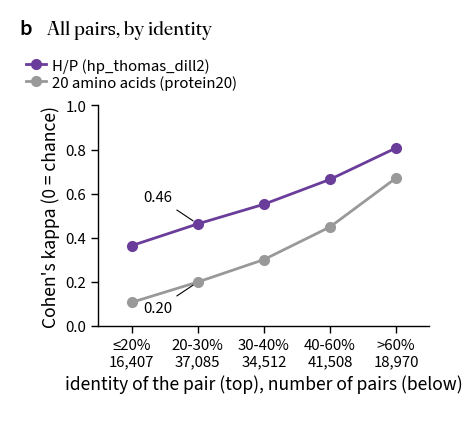

In [2]:
pairs_all = hc.add_identity_bin(pl.read_parquet(PAIR_TABLE)).filter(pl.col("n_cols") >= MIN_COLS)
rows_b = []
for a in (HP, AA):
    for b in hc.IDENTITY_LABELS:
        x = pairs_all.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b))["kappa"].to_numpy()
        m, lo, hi = hc.bootstrap_mean_ci(x)
        rows_b.append({"alphabet": a, "identity_bin": b, "n_pairs": x.size, "kappa": m, "kappa_lo": lo, "kappa_hi": hi})
kappa_bins = pl.DataFrame(rows_b)
BIN_SHOWN = {"<20%": "≤20%", "20-30%": "20-30%", "30-40%": "30-40%", "40-60%": "40-60%", ">=60%": ">60%"}
check(list(BIN_SHOWN) == hc.IDENTITY_LABELS, "identity bin labels changed in hp_conservation_utils")
kc = {(r["alphabet"], r["identity_bin"]): r for r in kappa_bins.iter_rows(named=True)}
ratio_by_bin = {b: kc[(HP, b)]["kappa"] / kc[(AA, b)]["kappa"] for b in hc.IDENTITY_LABELS}
print(kappa_bins.with_columns(pl.col("kappa", "kappa_lo", "kappa_hi").round(4),
                              pl.col("identity_bin").cast(pl.String).replace_strict(ratio_by_bin, return_dtype=pl.Float64)
                              .round(2).alias("hp_over_aa")))

check(hashlib.sha256(KAPPA_TSV.read_bytes()).hexdigest() == KAPPA_TSV_SHA256, f"{KAPPA_TSV.name} changed")
tsv = pl.read_csv(KAPPA_TSV, separator="\t", comment_prefix="#")
for a in (HP, AA):
    mine, ref = kc[(a, BIN)], tsv.filter(pl.col("alphabet") == a).row(0, named=True)
    for col in ("kappa", "kappa_lo", "kappa_hi"):
        check(round(mine[col], 4) == ref[col], f"{a} {col}: {mine[col]:.4f} here, {ref[col]} in the PR 53 table")
    check(mine["n_pairs"] == ref["n_pairs"], f"{a}: {mine['n_pairs']} pairs here, {ref['n_pairs']} in the table")
print(f"\n{BIN} bin matches the PR 53 table to 4 decimals for {HP} and {AA}.")
n_pairs = kc[(HP, BIN)]["n_pairs"]


def draw_panel_b(cv, ox, oy):
    """Kappa by identity bin, H/P (purple) and 20 amino acids (grey)."""
    cv.title(ox, oy + 50, "b", "All pairs, by identity")
    ax = cv.axes(ox + 10, oy + 13, 42, 28)
    xs = np.arange(len(hc.IDENTITY_LABELS))
    for a, color, label in [(HP, C_HP, f"H/P ({HP})"), (AA, C_AA, "20 amino acids (protein20)")]:
        ax.plot(xs, [kc[(a, b)]["kappa"] for b in hc.IDENTITY_LABELS], color=color, marker="o", label=label)
    i = hc.IDENTITY_LABELS.index(BIN)
    for a, dy in [(HP, 0.12), (AA, -0.12)]:
        v = kc[(a, BIN)]["kappa"]
        ax.annotate(f"{v:.2f}", (i, v), (i - 0.6, v + dy), fontsize=6, ha="center", va="center",
                    arrowprops=dict(arrowstyle="-", lw=0.4, color="black", shrinkA=0, shrinkB=2))
    ax.set_xticks(xs, [f"{BIN_SHOWN[b]}\n{kc[(HP, b)]['n_pairs']:,}" for b in hc.IDENTITY_LABELS])
    ax.set_xlim(-0.5, len(xs) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlabel("identity of the pair (top), number of pairs (below)")
    ax.set_ylabel("Cohen's kappa (0 = chance)")
    ax.legend(loc="lower left", bbox_to_anchor=(-0.24, 1.04), borderaxespad=0, labelspacing=0.15)
    return ax


cv = Canvas(58, 56)
draw_panel_b(cv, 2, 2)
PANELS.mkdir(parents=True, exist_ok=True)
cv.fig.savefig(PANELS / "fig1b_kappa_by_identity_pfam_a_38.2_seed.png", dpi=300)

## 2. The method on one pair (Figure 1c)

kmerseek encodes both proteins in H/P, finds every 19-letter H/P word they share (a shared 19-mer,
the seed), and joins shared 19-mers that overlap on one diagonal (the same offset between the two
proteins' positions, no gap) into a region. The joining rule here reproduced kmerseek's 147
regions exactly on the COL9A1 pair of notebook 244, in the first version of this notebook
(commit `5f3fadb`).

The pair is chosen by a rule applied in code, not by eye:

1. Pfam seed pairs at 20-30% identity whose longest H/P same-class run is at least 19, both
   sequences reviewed Swiss-Prot entries of at most 700 residues with only the 20 standard amino
   acids, the seed sequence identical to Swiss-Prot 2026_03.
2. The run is not low-complexity: no residue makes up more than 20% of it, and its hydrophobic
   share is between 0.3 and 0.7. At most 30% of its residues are identical.
3. Ranked by the number of shared H/P 19-mers off the run's diagonal across the full proteins
   (fewest first, so the dot plot is not cluttered), then by identity in the run (lowest first),
   then by family and name.

Next to the H/P dot plot is the amino-acid dot plot at the k with about the same information per
word: an H/P letter carries `B_alpha` bits in Swiss-Prot and an amino acid
`B_aa = -log2(sum of squared amino-acid shares)` bits, so `k_aa = ceil(19 B_alpha / B_aa)`.

Swiss-Prot 2026_03: 575,748 sequences; B_alpha = 0.967 bits per H/P letter, B_aa = 4.064 bits per amino acid; an H/P 19-mer carries 18.4 bits, so k_aa = 5 (20.3 bits)
pairs with a run >= 19, both reviewed: 226; with Swiss-Prot sequences <= 700 aa matching the seed: 144; passing the low-complexity and identity rule: 20
shape: (8, 15)
┌─────────┬─────────────────┬─────────────────────┬─────────────────────┬───────┬───────┬───────────┬─────┬───────┬───────┬──────────────┬─────────────────┬─────────────┬───────────────────┬────────────────────┐
│ family  ┆ family_id       ┆ query               ┆ target              ┆ q_len ┆ t_len ┆ seqid_ali ┆ run ┆ q_run ┆ t_run ┆ run_identity ┆ run_top_residue ┆ run_h_share ┆ hp_19mers_on_diag ┆ hp_19mers_off_diag │
│ ---     ┆ ---             ┆ ---                 ┆ ---                 ┆ ---   ┆ ---   ┆ ---       ┆ --- ┆ ---   ┆ ---   ┆ ---          ┆ ---             ┆ ---         ┆ ---               ┆ ---                │
│ str     ┆ str             ┆

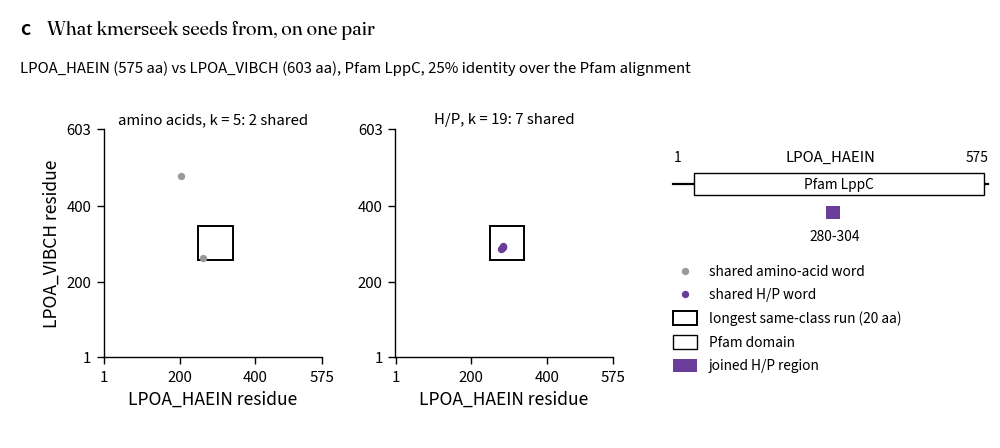

In [3]:
cand_pairs = (
    pairs_all.filter((pl.col("alphabet") == HP) & (pl.col("identity_bin") == BIN) & (pl.col("longest_run") >= K_HP))
    .filter(pl.col("query").map_elements(reviewed, return_dtype=pl.Boolean)
            & pl.col("target").map_elements(reviewed, return_dtype=pl.Boolean))
)
aln = pl.read_parquet(ALIGNMENTS).select("family", "query", "target", "qaln", "taln")
cand_pairs = cand_pairs.join(aln, on=["family", "query", "target"], how="inner")
want = {n.split("/")[0] for n in cand_pairs["query"].to_list() + cand_pairs["target"].to_list()}

# One pass over Swiss-Prot 2026_03: letter counts for k*, and the full sequences of the candidates.
sprot_counts = np.zeros(256, dtype=np.int64)
sprot_seqs, n_sprot_seq, name, buf = {}, 0, None, []
with gzip.open(SWISSPROT, "rt") as fh:
    for line in fh:
        if line.startswith(">"):
            if name in want:
                sprot_seqs[name] = "".join(buf)
            n_sprot_seq += 1
            name, buf = line.split("|")[2].split()[0], []
        else:
            s = line.strip()
            sprot_counts += np.bincount(np.frombuffer(s.encode(), dtype=np.uint8), minlength=256)
            if name in want:
                buf.append(s)
    if name in want:
        sprot_seqs[name] = "".join(buf)
aa_counts = np.array([sprot_counts[ord(r)] for r in STANDARD], dtype=float)
b_aa = -math.log2(((aa_counts / aa_counts.sum()) ** 2).sum())
n_h, n_p = (int(sum(sprot_counts[ord(r)] for r in cl)) for cl in (H_RES, P_RES))
n_res = n_h + n_p
h_share, p_share = n_h / n_res, n_p / n_res
pr_same_chance = h_share * h_share + p_share * p_share  # h_query h_target + p_query p_target, Swiss-Prot shares
b_alpha = -math.log2(pr_same_chance)
K_AA = math.ceil(K_HP * b_alpha / b_aa)
print(f"Swiss-Prot 2026_03: {n_sprot_seq:,} sequences; B_alpha = {b_alpha:.3f} bits per H/P letter, "
      f"B_aa = {b_aa:.3f} bits per amino acid; an H/P {K_HP}-mer carries {K_HP * b_alpha:.1f} bits, "
      f"so k_aa = {K_AA} ({K_AA * b_aa:.1f} bits)")


def shared_kmers(a: str, b: str, k: int) -> np.ndarray:
    """Every (start in a, start in b) of a word of length k the two strings share, 1-based."""
    words = {}
    for j in range(len(b) - k + 1):
        words.setdefault(b[j:j + k], []).append(j)
    out = [(i + 1, j + 1) for i in range(len(a) - k + 1) for j in words.get(a[i:i + k], [])]
    return np.array(out, dtype=np.int64).reshape(-1, 2)


def join_regions(shared: np.ndarray, k: int) -> list[tuple[int, int, int, int]]:
    """Shared k-mers that overlap on one diagonal joined into regions: (a_start, a_end, b_start, b_end), 1-based."""
    regions = []
    for d in sorted(set(shared[:, 0] - shared[:, 1])):
        starts = np.sort(shared[shared[:, 0] - shared[:, 1] == d, 0])
        breaks = np.flatnonzero(np.diff(starts) > 1)
        for s, e in zip(np.r_[starts[0], starts[breaks + 1]], np.r_[starts[breaks], starts[-1]]):
            regions.append((int(s), int(e + k - 1), int(s - d), int(e + k - 1 - d)))
    return regions


def longest_run_residues(qaln: str, taln: str, q_start: int, t_start: int) -> tuple[int, int, int]:
    """Length and 1-based residue starts of the first longest same-class run in a gapped alignment."""
    qi, ti, cur, best = q_start, t_start, 0, (0, 0, 0)
    for a, b in zip(qaln, taln):
        ga, gb = a.isalpha(), b.isalpha()
        if ga and gb and TO_CLASS[a.upper()] == TO_CLASS[b.upper()]:
            cur += 1
            if cur > best[0]:
                best = (cur, qi - cur + 1, ti - cur + 1)
        else:
            cur = 0
        qi += ga
        ti += gb
    return best


rows = []
for r in cand_pairs.iter_rows(named=True):
    qn, qs0, _ = seed_coords(r["query"])
    tn, ts0, _ = seed_coords(r["target"])
    if qn not in sprot_seqs or tn not in sprot_seqs:
        continue
    q_seq, t_seq = sprot_seqs[qn], sprot_seqs[tn]
    if max(len(q_seq), len(t_seq)) > METHOD_MAX_LEN or set(q_seq + t_seq) - set(STANDARD):
        continue
    seed_q = re.sub(r"[^A-Za-z]", "", r["qaln"]).upper()
    seed_t = re.sub(r"[^A-Za-z]", "", r["taln"]).upper()
    if q_seq[qs0 - 1:qs0 - 1 + len(seed_q)] != seed_q or t_seq[ts0 - 1:ts0 - 1 + len(seed_t)] != seed_t:
        continue  # seed sequence differs from Swiss-Prot 2026_03
    run_len, q_run, t_run = longest_run_residues(r["qaln"], r["taln"], qs0, ts0)
    check(run_len == r["longest_run"], f"{r['query']}: run {run_len}, 230 says {r['longest_run']}")
    q_r, t_r = q_seq[q_run - 1:q_run - 1 + run_len], t_seq[t_run - 1:t_run - 1 + run_len]
    hp_shared = shared_kmers(encode(q_seq), encode(t_seq), K_HP)
    on_diag = hp_shared[:, 0] - hp_shared[:, 1] == q_run - t_run
    rows.append({"family": r["family"], "family_id": r["family_id"], "query": r["query"], "target": r["target"],
                 "q_len": len(q_seq), "t_len": len(t_seq), "seqid_ali": r["seqid_ali"], "run": run_len,
                 "q_run": q_run, "t_run": t_run,
                 "run_identity": sum(a == b for a, b in zip(q_r, t_r)) / run_len,
                 "run_top_residue": max(q_r.count(c) for c in set(q_r)) / run_len,
                 "run_h_share": encode(q_r).count("H") / run_len,
                 "hp_19mers_on_diag": int(on_diag.sum()), "hp_19mers_off_diag": int((~on_diag).sum())})
method_cands = pl.DataFrame(rows)
method_pass = method_cands.filter(
    (pl.col("run_top_residue") <= METHOD_MAX_TOP) & pl.col("run_h_share").is_between(*METHOD_H_RANGE)
    & (pl.col("run_identity") <= METHOD_MAX_IDENT)
).sort("hp_19mers_off_diag", "run_identity", "family", "query")
print(f"pairs with a run >= {K_HP}, both reviewed: {cand_pairs.height}; with Swiss-Prot sequences <= "
      f"{METHOD_MAX_LEN} aa matching the seed: {method_cands.height}; passing the low-complexity and identity "
      f"rule: {method_pass.height}")
print(method_pass.head(8).with_columns(pl.col("seqid_ali", "run_identity", "run_top_residue", "run_h_share").round(2)))
mp = method_pass.row(0, named=True)
mq_name, mt_name = mp["query"].split("/")[0], mp["target"].split("/")[0]
mq, mt = sprot_seqs[mq_name], sprot_seqs[mt_name]
_, mq_dom0, mq_dom1 = seed_coords(mp["query"])
m_hp = shared_kmers(encode(mq), encode(mt), K_HP)
m_aa = shared_kmers(mq, mt, K_AA)
m_diag = mp["q_run"] - mp["t_run"]
m_regions = [r for r in join_regions(m_hp, K_HP) if r[0] - r[2] == m_diag]
m_aa_on_diag = int((m_aa[:, 0] - m_aa[:, 1] == m_diag).sum()) if len(m_aa) else 0
mq_run = mq[mp["q_run"] - 1:mp["q_run"] - 1 + mp["run"]]
mt_run = mt[mp["t_run"] - 1:mp["t_run"] - 1 + mp["run"]]
m_run_ident = match_line(mq_run, mt_run).count("|")
m_run_same = match_line(encode(mq_run), encode(mt_run)).count("|")
check(len(m_regions) == 1, f"{len(m_regions)} H/P regions on the run's diagonal; the caption describes one")
mr0, mr1, mr_t0, mr_t1 = m_regions[0]
check(mr0 <= mp["q_run"] and mp["q_run"] + mp["run"] - 1 <= mr1, "the joined region does not cover the run")
m_region_seq_q, m_region_seq_t = mq[mr0 - 1:mr1], mt[mr_t0 - 1:mr_t1]
check(encode(m_region_seq_q) == encode(m_region_seq_t), "the joined region is not all same class")
print(f"joined H/P region: {mq_name} {mr0}-{mr1} ({mr1 - mr0 + 1} aa) with {mt_name} {mr_t0}-{mr_t1}; "
      f"{match_line(m_region_seq_q, m_region_seq_t).count('|')} of {mr1 - mr0 + 1} identical")
check(m_run_same == mp["run"], "the chosen run is not all same class")
print(f"\nchosen: {mp['family_id']} ({mp['family']}), {mq_name} ({len(mq)} aa) vs {mt_name} ({len(mt)} aa), "
      f"{100 * mp['seqid_ali']:.1f}% identity over the Pfam alignment")
print(f"shared H/P {K_HP}-mers: {len(m_hp)} ({mp['hp_19mers_on_diag']} on the run's diagonal); "
      f"shared amino-acid {K_AA}-mers: {len(m_aa)} ({m_aa_on_diag} on the run's diagonal)")
print(f"H/P regions on the run's diagonal ({mq_name} positions): " + ", ".join(f"{a}-{b}" for a, b, _, _ in m_regions))
w = max(len(mq_name), len(mt_name))
print(f"{mq_name:<{w}} {mp['q_run']:>4} {mq_run}")
print(f"{'':<{w}} {'':>4} {match_line(mq_run, mt_run)} {m_run_ident} of {mp['run']} identical")
print(f"{mt_name:<{w}} {mp['t_run']:>4} {mt_run}")
print(f"{'':<{w}} {'':>4} {encode(mq_run)}")
print(f"{'':<{w}} {'':>4} {match_line(encode(mq_run), encode(mt_run))} {m_run_same} of {mp['run']} same class")
print(f"{'':<{w}} {'':>4} {encode(mt_run)}")


def dotplot(ax, pts, color, title):
    ax.scatter(pts[:, 0], pts[:, 1], s=7, color=color, linewidths=0, zorder=3)
    pad = 35
    ax.add_patch(Rectangle((mp["q_run"] - pad, mp["t_run"] - pad), mp["run"] + 2 * pad, mp["run"] + 2 * pad,
                           fill=False, lw=0.7, ec="black"))
    ax.set_xlim(0, len(mq))
    ax.set_ylim(0, len(mt))
    ax.set_xticks([1, 200, 400, len(mq)])
    ax.set_yticks([1, 200, 400, len(mt)])
    ax.set_aspect("equal")
    ax.set_xlabel(f"{mq_name} residue")
    ax.set_title(title, fontsize=6, pad=2)


def draw_panel_c(cv, ox, oy):
    """Amino-acid and H/P dot plots of one pair, and the joined H/P region on the protein."""
    cv.title(ox, oy + 50, "c", f"What kmerseek seeds from, on one pair")
    cv.text(ox, oy + 45.8, f"{mq_name} ({len(mq)} aa) vs {mt_name} ({len(mt)} aa), Pfam {mp['family_id']}, "
            f"{100 * mp['seqid_ali']:.0f}% identity over the Pfam alignment", fontsize=6)
    ax1 = cv.axes(ox + 10, oy + 9, 29, 29)
    dotplot(ax1, m_aa, C_AA, f"amino acids, k = {K_AA}: {len(m_aa)} shared")
    ax1.set_ylabel(f"{mt_name} residue")
    ax2 = cv.axes(ox + 47, oy + 9, 29, 29)
    dotplot(ax2, m_hp, C_HP, f"H/P, k = {K_HP}: {len(m_hp)} shared")
    x4, wd = ox + 83, 40.0
    sx = lambda r: x4 + (r - 1) / (len(mq) - 1) * wd
    y = oy + 31
    cv.text((sx(1) + sx(len(mq))) / 2, y + 3.4, mq_name, fontsize=6, ha="center")
    cv.text(sx(1), y + 3.4, "1", fontsize=5.5)
    cv.text(sx(len(mq)), y + 3.4, f"{len(mq)}", fontsize=5.5, ha="right")
    cv.line([sx(1), sx(len(mq))], [y, y], color="black", lw=0.8)
    cv.rect(sx(mq_dom0), y - 1.4, sx(mq_dom1) - sx(mq_dom0), 2.8, facecolor="white", edgecolor="black", lw=0.5, zorder=3)
    cv.text((sx(mq_dom0) + sx(mq_dom1)) / 2, y, f"Pfam {mp['family_id']}", fontsize=5.5, ha="center", zorder=4)
    for a, b, _, _ in m_regions:
        cv.rect(sx(a), y - 4.4, max(sx(b) - sx(a), 0.6), 1.6, facecolor=C_HP, edgecolor="none")
    run_x = (sx(mp["q_run"]) + sx(mp["q_run"] + mp["run"] - 1)) / 2
    cv.text(run_x, y - 6.6, ", ".join(f"{a}-{b}" for a, b, _, _ in m_regions), fontsize=5.5, ha="center")
    keys = [("dot_aa", "shared amino-acid word"), ("dot_hp", "shared H/P word"), ("box", f"longest same-class run ({mp['run']} aa)"),
            ("dom", "Pfam domain"), ("bar", "joined H/P region")]
    for n, (kind, label) in enumerate(keys):
        yy = oy + 20 - n * 3.0
        if kind.startswith("dot"):
            cv.ax.scatter([x4 + 1.5], [yy], s=7, color=C_AA if kind == "dot_aa" else C_HP, linewidths=0)
        elif kind == "box":
            cv.rect(x4, yy - 0.9, 3.0, 1.8, facecolor="none", edgecolor="black", lw=0.7)
        elif kind == "dom":
            cv.rect(x4, yy - 0.9, 3.0, 1.8, facecolor="white", edgecolor="black", lw=0.5)
        else:
            cv.rect(x4, yy - 0.8, 3.0, 1.6, facecolor=C_HP, edgecolor="none")
        cv.text(x4 + 4.5, yy, label, fontsize=5.5)
    return ax1, ax2


cv = Canvas(126, 56)
draw_panel_c(cv, 2, 2)
cv.fig.savefig(PANELS / f"fig1c_dotplots_{mq_name}_{mt_name}_hp_thomas_dill2_k19_swissprot.png", dpi=300)

## 3. One typical pair (Figure 1a)

Rule, applied in code: among the 20-30% pairs whose longest H/P same-class run equals the bin's
median, keep those with no gap, at most 80 aligned positions, and both sequences reviewed
Swiss-Prot entries; take the pair whose own kappa is closest to the bin's mean kappa.

candidates after the rule: 3
shape: (3, 7)
┌─────────┬───────────┬──────────────────┬──────────────────┬────────┬───────────┬───────┐
│ family  ┆ family_id ┆ query            ┆ target           ┆ n_cols ┆ seqid_ali ┆ kappa │
│ ---     ┆ ---       ┆ ---              ┆ ---              ┆ ---    ┆ ---       ┆ ---   │
│ str     ┆ str       ┆ str              ┆ str              ┆ i64    ┆ f64       ┆ f64   │
╞═════════╪═══════════╪══════════════════╪══════════════════╪════════╪═══════════╪═══════╡
│ PF01418 ┆ HTH_6     ┆ RPIR_ECOLI/14-90 ┆ Y143_HAEIN/5-81  ┆ 77     ┆ 0.208     ┆ 0.451 │
│ PF01938 ┆ TRAM      ┆ YFJO_BACSU/11-68 ┆ RLMD_ECOLI/10-67 ┆ 58     ┆ 0.241     ┆ 0.488 │
│ PF08220 ┆ HTH_DeoR  ┆ ULAR_ECOLI/6-62  ┆ AGAR_ECOLI/18-74 ┆ 57     ┆ 0.263     ┆ 0.497 │
└─────────┴───────────┴──────────────────┴──────────────────┴────────┴───────────┴───────┘

Pfam PF01418 (HTH_6), 77 aligned positions, no gaps
RPIR_ECOLI   14 IGLAPYLRMKQEGMTENESRIVEWLLKPGNLSCAPAIKDVAEALAVSEAMIVKVSKLLGFSGFRNLRSA

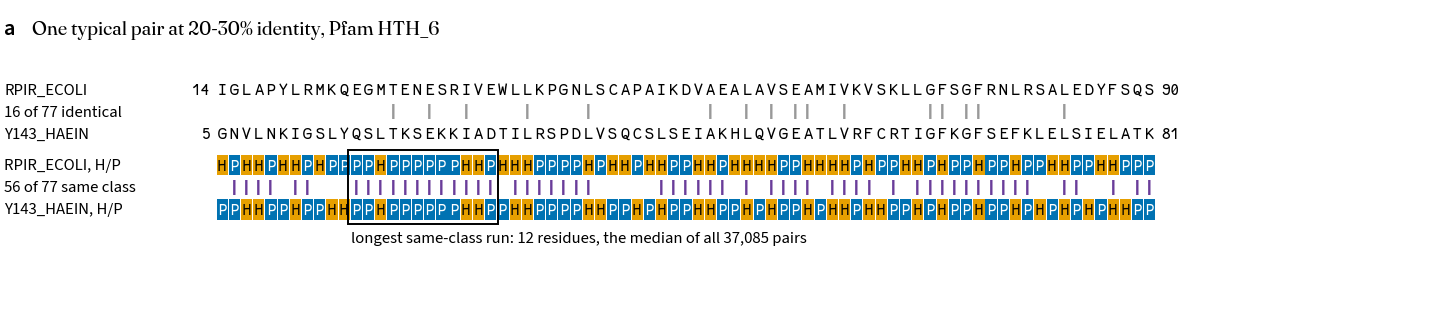

In [4]:
hp = pairs_all.filter((pl.col("alphabet") == HP) & (pl.col("identity_bin") == BIN))
hp_aln = hp.join(aln, on=["family", "query", "target"], how="inner").sort("family", "query", "target")
check(hp_aln.height == n_pairs == hp.height, "an alignment is missing for a pair in the bin")
median_run = float(hp["longest_run"].median())
check(median_run == int(median_run), f"median run {median_run} is not a whole number")
cand = (
    hp_aln.filter(pl.col("longest_run") == int(median_run))
    .filter(pl.col("qaln").str.len_chars() == pl.col("n_cols"))
    .filter(pl.col("n_cols") <= PANEL_A_MAX_COLS)
    .filter(pl.col("query").map_elements(reviewed, return_dtype=pl.Boolean)
            & pl.col("target").map_elements(reviewed, return_dtype=pl.Boolean))
    .with_columns((pl.col("kappa") - hp["kappa"].mean()).abs().alias("kappa_distance"))
    .sort("kappa_distance", "family", "query")
)
print(f"candidates after the rule: {cand.height}")
print(cand.select("family", "family_id", "query", "target", "n_cols", pl.col("seqid_ali").round(3), pl.col("kappa").round(3)).head(5))
pick = cand.row(0, named=True)
qe, te = pick["qaln"], pick["taln"]
L_e = len(qe)
qe_c, te_c = encode(qe), encode(te)
cm_e = match_line(qe_c, te_c)
runs_e = [(m.start(), m.end()) for m in re.finditer(r"\|+", cm_e)]
longest_e = max(e - s for s, e in runs_e)
longest_runs_e = [(s, e) for s, e in runs_e if e - s == longest_e]
qname, qs_e, _ = seed_coords(pick["query"])
tname, ts_e, _ = seed_coords(pick["target"])
n_ident_e, n_same_e = match_line(qe, te).count("|"), cm_e.count("|")
check(longest_e == pick["longest_run"] == median_run, "longest run differs from 230's")
check(abs(n_same_e / L_e - pick["agree"]) < 1e-9, "class agreement differs from 230's")
w = max(len(qname), len(tname))
print(f"\nPfam {pick['family']} ({pick['family_id']}), {L_e} aligned positions, no gaps")
print(f"{qname:<{w}} {qs_e:>4} {qe} {qs_e + L_e - 1}")
print(f"{'':<{w}} {'':>4} {match_line(qe, te)} {n_ident_e} of {L_e} identical")
print(f"{tname:<{w}} {ts_e:>4} {te} {ts_e + L_e - 1}\n")
print(f"{qname:<{w}} {'':>4} {qe_c}")
print(f"{'':<{w}} {'':>4} {cm_e} {n_same_e} of {L_e} same class")
print(f"{tname:<{w}} {'':>4} {te_c}")
print(f"{'':<{w}} {'':>4} " + "".join("^" if any(s <= i < e for s, e in longest_runs_e) else " " for i in range(L_e))
      + f" longest same-class run: {longest_e}")

PITCH_A = 1.55
X_SEQ_A = 27


def draw_panel_a(cv, ox, oy):
    """The median pair, residues and H/P classes, longest same-class run boxed."""
    cv.title(ox, oy + 36, "a", f"One typical pair at {BIN} identity, Pfam {pick['family_id']}")
    rows, _, _ = draw_pair_block(cv, ox, ox + X_SEQ_A, oy + 29, PITCH_A, (qname, tname), (qs_e, ts_e), (qe, te),
                                 (qe_c, te_c), outline=longest_runs_e)
    s, e = longest_runs_e[0]
    cv.text(ox + X_SEQ_A + s * PITCH_A, rows["tc"] - 3.6,
            f"longest same-class run: {e - s} residues, the median of all {n_pairs:,} pairs", fontsize=6)


cv = Canvas(183, 40)
draw_panel_a(cv, 0, 0)
cv.fig.savefig(PANELS / "fig1a_median_run_pair_pfam_a_38.2_seed_20-30pct.png", dpi=300)

## 4. Run lengths against independent positions and shuffles (Figure 3 draft)

The review of PR 95 moved this panel out of Figure 1: it explains why exact H/P seeds rarely reach
pairs at 20-30% identity, which is the mechanism behind Figure 3. Three curves for the 20-30% bin:

1. **Real pairs**: notebook 230's longest same-class run per pair, recomputed from the alignments
   here and checked against the saved value.
2. **Independent-position prediction**: for each pair, `Pr(agree)` is its share of aligned
   positions in the same class (notebook 230's `agree`). The chance of a run of at least k, if
   every aligned position kept its class on its own with that probability, is computed exactly
   (`hc.pr_longest_run_at_least`) and averaged over pairs. A run stops at an alignment gap, as it
   does for the real pairs. A version that joins each pair's aligned positions into one unbroken
   stretch is printed but not drawn.
3. **Shuffled**: the target's residues shuffled among its own residue positions (composition and
   gaps kept), 20 times per pair with a fixed seed.

The lower panel is real divided by predicted: 1 means real runs are as long as independent
positions give, above 1 that same-class positions cluster.

shape: (15, 6)
┌───────┬───────────┬─────┬───────────┬────────┬───────────────┐
│ pair  ┆ Pr(agree) ┆ k   ┆ simulated ┆ exact  ┆ within 4 s.e. │
│ ---   ┆ ---       ┆ --- ┆ ---       ┆ ---    ┆ ---           │
│ i64   ┆ f64       ┆ i64 ┆ f64       ┆ f64    ┆ bool          │
╞═══════╪═══════════╪═════╪═══════════╪════════╪═══════════════╡
│ 0     ┆ 0.729     ┆ 8   ┆ 0.9964    ┆ 0.9961 ┆ true          │
│ 0     ┆ 0.729     ┆ 12  ┆ 0.6872    ┆ 0.6842 ┆ true          │
│ 0     ┆ 0.729     ┆ 16  ┆ 0.2218    ┆ 0.2284 ┆ true          │
│ 9271  ┆ 0.717     ┆ 8   ┆ 0.9918    ┆ 0.9919 ┆ true          │
│ 9271  ┆ 0.717     ┆ 12  ┆ 0.6356    ┆ 0.629  ┆ true          │
│ 9271  ┆ 0.717     ┆ 16  ┆ 0.2002    ┆ 0.1965 ┆ true          │
│ 18542 ┆ 0.783     ┆ 8   ┆ 0.9758    ┆ 0.9776 ┆ true          │
│ 18542 ┆ 0.783     ┆ 12  ┆ 0.5846    ┆ 0.5836 ┆ true          │
│ 18542 ┆ 0.783     ┆ 16  ┆ 0.1786    ┆ 0.1841 ┆ true          │
│ 27813 ┆ 0.846     ┆ 8   ┆ 0.9994    ┆ 0.9994 ┆ true          │
│ 27813 ┆ 

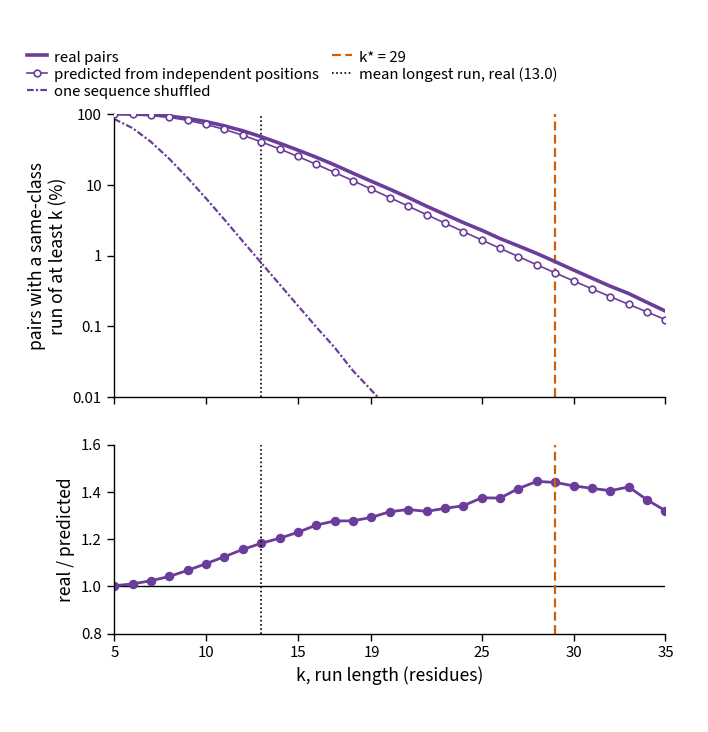

In [5]:
tab = hc.TABLES[HP]
rng = np.random.default_rng(0)
real_runs = np.empty(n_pairs, dtype=np.int64)
null_runs = np.empty((N_SHUFFLE, n_pairs), dtype=np.int64)
stretches = []
for i, (qa_s, ta_s) in enumerate(hp_aln.select("qaln", "taln").iter_rows()):
    qcl = tab[np.frombuffer(qa_s.encode(), dtype=np.uint8)]
    tcl = tab[np.frombuffer(ta_s.encode(), dtype=np.uint8)]
    both = (qcl != hc.GAP) & (tcl != hc.GAP)
    real_runs[i] = hc.longest_true_run((qcl == tcl) & both)
    res_idx = np.flatnonzero(tcl != hc.GAP)
    for r in range(N_SHUFFLE):
        shuffled = tcl.copy()
        shuffled[res_idx] = tcl[rng.permutation(res_idx)]
        null_runs[r, i] = hc.longest_true_run((qcl == shuffled) & both)
    stretches.append(hc.aligned_stretches(qa_s, ta_s))
check(np.array_equal(real_runs, hp_aln["longest_run"].to_numpy()), "recomputed runs differ from 230's")
pr_agree = hp_aln["agree"].to_numpy()
n_aligned = hp_aln["n_cols"].to_numpy()
check(np.array_equal(np.array([s.sum() for s in stretches]), n_aligned), "stretch lengths do not add up to n_cols")

ks = np.array(KS)
pred_pair = hc.pr_longest_run_at_least(pr_agree, stretches, ks)
pred_one_pair = hc.pr_longest_run_at_least(pr_agree, [np.array([n]) for n in n_aligned], ks)
share_real = (real_runs[None, :] >= ks[:, None]).mean(axis=1)
share_pred = pred_pair.mean(axis=1)
share_pred_one = pred_one_pair.mean(axis=1)
share_null = (null_runs[:, None, :] >= ks[None, :, None]).mean(axis=2).mean(axis=0)
mean_run, mean_run_null = float(real_runs.mean()), float(null_runs.mean())
mean_pr_agree = float(pr_agree.mean())

sim_rng = np.random.default_rng(1)
sim_rows = []
for i in np.linspace(0, n_pairs - 1, 5).astype(int):
    best = np.zeros(N_SIM, dtype=np.int64)
    for L in stretches[i]:
        draws = sim_rng.random((N_SIM, L)) < pr_agree[i]
        dd = np.diff(np.pad(draws, ((0, 0), (1, 1))).astype(np.int8), axis=1)
        for s in range(N_SIM):
            st, en = np.flatnonzero(dd[s] == 1), np.flatnonzero(dd[s] == -1)
            if st.size:
                best[s] = max(best[s], (en - st).max())
    for k in (8, 12, 16):
        sim, exact = (best >= k).mean(), pred_pair[k - KS[0], i]
        sim_rows.append({"pair": i, "Pr(agree)": round(pr_agree[i], 3), "k": k, "simulated": sim, "exact": exact,
                         "within 4 s.e.": bool(abs(sim - exact) <= 4 * math.sqrt(max(exact * (1 - exact), 1e-12) / N_SIM))})
sim_check = pl.DataFrame(sim_rows)
print(sim_check.with_columns(pl.col("simulated", "exact").round(4)))
check(sim_check["within 4 s.e."].all(), "exact prediction disagrees with simulation")

n_other = int(sprot_counts.sum()) - n_res
kstar_exact = math.log2(n_res) / b_alpha
kstar = math.ceil(kstar_exact)
print(f"\nSwiss-Prot 2026_03: {n_res:,} residues with an H/P class, {n_other:,} other letters; "
      f"h = {h_share:.4f}, p = {p_share:.4f}")
print(f"B_alpha = -log2({pr_same_chance:.4f}) = {b_alpha:.4f} bits; k* = ceil({math.log2(n_res):.3f} / {b_alpha:.4f}) "
      f"= ceil({kstar_exact:.2f}) = {kstar}")

at = lambda arr, k: float(arr[k - KS[0]])
tail = pl.DataFrame({
    "k": KS_TABLE,
    "real_pct": [100 * at(share_real, k) for k in KS_TABLE],
    "predicted_pct": [100 * at(share_pred, k) for k in KS_TABLE],
    "real_over_predicted": [at(share_real, k) / at(share_pred, k) for k in KS_TABLE],
    "predicted_one_stretch_pct": [100 * at(share_pred_one, k) for k in KS_TABLE],
    "real_over_one_stretch": [at(share_real, k) / at(share_pred_one, k) for k in KS_TABLE],
    "shuffled_pct": [100 * at(share_null, k) for k in KS_TABLE],
})
print(f"\nmean Pr(agree) over pairs: {mean_pr_agree:.3f}; mean longest H/P run: real {mean_run:.2f} "
      f"(median {median_run:.0f}), shuffled {mean_run_null:.2f}")
print(tail.with_columns(pl.exclude("k").round(3)))
tail_ks = range(K_HP, KS[-1] + 1)
ratio_lo, ratio_hi = (f(at(share_real, k) / at(share_pred, k) for k in tail_ks) for f in (min, max))
one_lo, one_hi = (f(at(share_real, k) / at(share_pred_one, k) for k in tail_ks) for f in (min, max))
first_above = min(k for k in KS if at(share_real, k) > at(share_pred, k))
print(f"real pairs above the prediction from k = {first_above}; at k = {K_HP}-{KS[-1]}, real / predicted = "
      f"{ratio_lo:.2f}-{ratio_hi:.2f}; against the one-stretch version {one_lo:.2f}-{one_hi:.2f}")


def draw_fig3_draft(cv, ox, oy):
    """Top: share of pairs with a run of at least k. Bottom: real divided by predicted."""
    ax = cv.axes(ox + 12, oy + 42, 70, 36)
    ax.plot(KS, 100 * share_real, color=C_HP, lw=1.3, zorder=3, label="real pairs")
    ax.plot(KS, 100 * share_pred, color=C_HP, lw=0.6, marker="o", ms=2.4, mfc="white", mew=0.6, zorder=4,
            label="predicted from independent positions")
    ax.plot(KS, 100 * share_null, color=C_HP, lw=0.8, ls=(0, (3, 1, 1, 1)), zorder=2, label="one sequence shuffled")
    ax.axvline(kstar, color=C_KSTAR, lw=0.8, ls=(0, (4, 2)), zorder=0, label=f"k* = {kstar}")
    ax.axvline(mean_run, color="black", lw=0.6, ls=(0, (1, 1.5)), zorder=0, label=f"mean longest run, real ({mean_run:.1f})")
    ax.set_yscale("log")
    ax.set_ylim(0.01, 100)
    ax.set_yticks([0.01, 0.1, 1, 10, 100], ["0.01", "0.1", "1", "10", "100"])
    ax.minorticks_off()
    ax.set_xlim(KS[0], KS[-1])
    ax.set_xticks([5, 10, 15, 19, 25, 30, 35])
    ax.tick_params(labelbottom=False)
    ax.set_ylabel("pairs with a same-class\nrun of at least k (%)")
    ax.legend(loc="lower left", bbox_to_anchor=(-0.17, 1.03), ncol=2, borderaxespad=0, labelspacing=0.15, columnspacing=0.8)
    axr = cv.axes(ox + 12, oy + 12, 70, 24)
    axr.axhline(1, color="black", lw=0.5)
    axr.plot(KS, share_real / share_pred, color=C_HP, lw=1.0, marker="o", ms=2.4)
    axr.axvline(kstar, color=C_KSTAR, lw=0.8, ls=(0, (4, 2)))
    axr.axvline(mean_run, color="black", lw=0.6, ls=(0, (1, 1.5)))
    axr.set_xlim(KS[0], KS[-1])
    axr.set_xticks([5, 10, 15, 19, 25, 30, 35])
    axr.set_ylim(0.8, 1.6)
    axr.set_yticks([0.8, 1.0, 1.2, 1.4, 1.6])
    axr.set_xlabel("k, run length (residues)")
    axr.set_ylabel("real / predicted")
    return ax, axr


cv = Canvas(89, 92)
draw_fig3_draft(cv, 2, 0)
FIG3 = "fig3_draft_hp_run_length_pfam_a_38.2_seed_20-30pct"
cv.fig.savefig(FIG / f"{FIG3}.pdf")
cv.fig.savefig(FIG / f"{FIG3}.png", dpi=450)

## 5. Helix, strand and coil: is secondary structure available for the seed pairs?

The Figure 1 brief asked to repeat the run-length comparison by DSSP helix, strand and coil if the
seed alignments carry secondary structure. Pfam stores it as `#=GR <sequence> SS` lines. The cell
counts every per-sequence (`#=GR`) and per-column (`#=GC`) annotation type in the Pfam-A 38.2 seed.

In [6]:
ann_counts = {}
with gzip.open(PFAM_SEED, "rb") as fh:
    for line in fh:
        if line.startswith(b"#=GR ") or line.startswith(b"#=GC "):
            parts = line.split()
            key = (parts[0].decode(), (parts[2] if parts[0] == b"#=GR" else parts[1]).decode())
            ann_counts[key] = ann_counts.get(key, 0) + 1
n_ss = sum(v for (kind, tag), v in ann_counts.items() if tag in ("SS", "SS_cons"))
print("annotation lines in Pfam-A 38.2 seed: " + "; ".join(f"{k} {t}: {v:,}" for (k, t), v in sorted(ann_counts.items())))
print(f"secondary-structure lines (SS or SS_cons): {n_ss}")

annotation lines in Pfam-A 38.2 seed: #=GC RF: 111; #=GC seq_cons: 30,134; #=GR AS: 658; #=GR pAS: 67,854; #=GR sAS: 13,398
secondary-structure lines (SS or SS_cons): 0


The seed file has no secondary-structure lines, so the helix, strand and coil split cannot be made
from the seed alignments. It would need structures mapped onto each seed sequence (PDB or
AlphaFold, then DSSP).

## 6. Figure 1

183 mm wide (two Nature columns). Fonts: Fraunces for panel titles, Source Sans 3 for text,
Fantasque Sans Mono for sequences, embedded as TrueType. Colour says which alphabet and shape
says what the mark is: amber and blue squares are the H and P classes, purple is `hp_thomas_dill2`,
grey is the 20 amino acids; a black outline is the longest same-class run. The table compares
every number in the brief with what was computed; the notebook stops before drawing if any differs.

shape: (8, 5)
┌─────────────────────────────────┬─────────┬───────────┬──────────────────┬─────────┐
│ number                          ┆ brief   ┆ computed  ┆ computed_rounded ┆ matches │
│ ---                             ┆ ---     ┆ ---       ┆ ---              ┆ ---     │
│ str                             ┆ f64     ┆ f64       ┆ f64              ┆ bool    │
╞═════════════════════════════════╪═════════╪═══════════╪══════════════════╪═════════╡
│ pairs at 20-30% identity        ┆ 37085.0 ┆ 37085.0   ┆ 37085.0          ┆ true    │
│ kappa H/P (hp_thomas_dill2)     ┆ 0.46    ┆ 0.462555  ┆ 0.46             ┆ true    │
│ kappa 20 amino acids (protein2… ┆ 0.2     ┆ 0.198837  ┆ 0.2              ┆ true    │
│ mean longest H/P run, real      ┆ 13.0    ┆ 13.008251 ┆ 13.0             ┆ true    │
│ mean longest H/P run, shuffled  ┆ 6.3     ┆ 6.327875  ┆ 6.3              ┆ true    │
│ pairs with run >= 19 (%)        ┆ 11.0    ┆ 11.163543 ┆ 11.0             ┆ true    │
│ pairs with run >= 30 (%)   

fig1.pdf fonts: ['DHKLXC+SourceSans3-Regular', 'DHKLXC+SourceSans3-SemiBold', 'DKCQCQ+FantasqueSansMNFM-Regular', 'GQGMZL+Fraunces-72ptNonWonky', 'HDDGSM+FantasqueSansMNFM-Bold'] | TrueType: True
fig3_draft_hp_run_length_pfam_a_38.2_seed_20-30pct.pdf fonts: ['DHKLXC+SourceSans3-Regular'] | TrueType: True


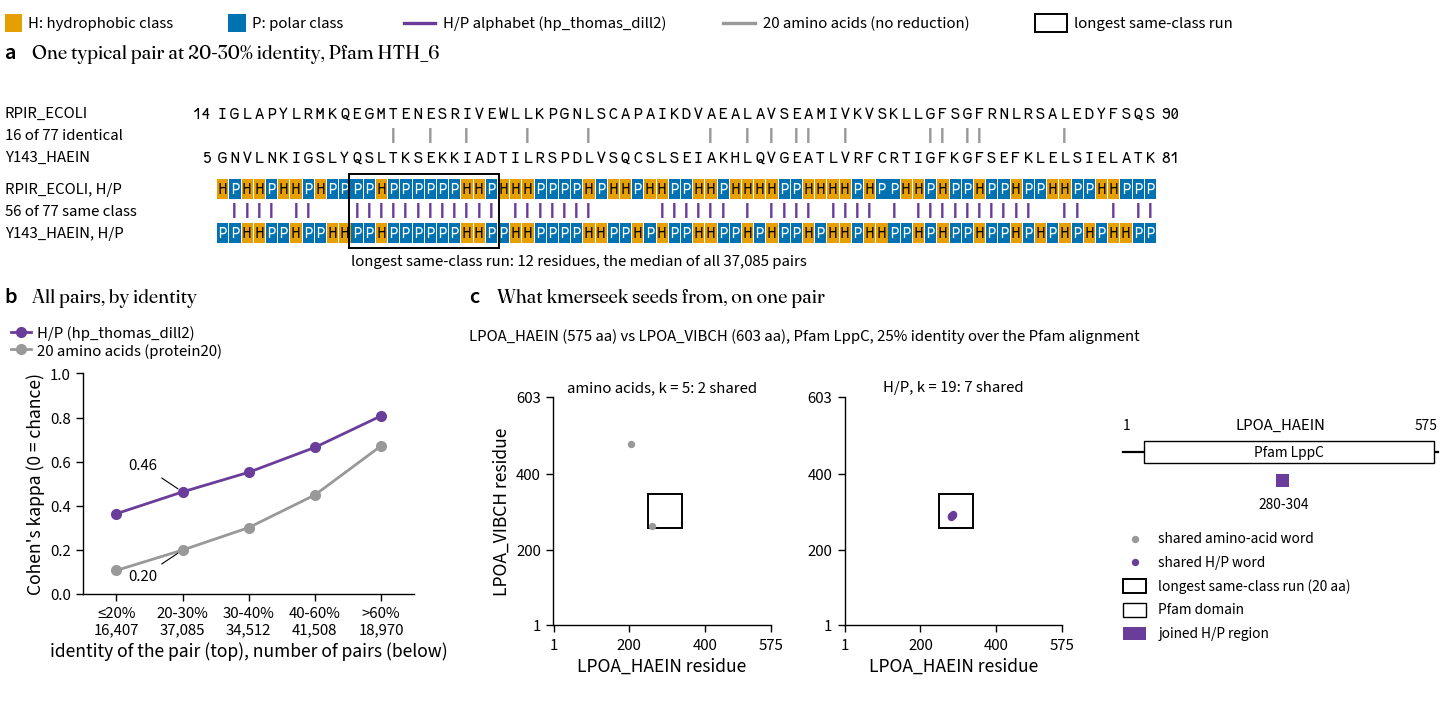

In [7]:
computed = {
    "pairs at 20-30% identity": n_pairs,
    "kappa H/P (hp_thomas_dill2)": kc[(HP, BIN)]["kappa"],
    "kappa 20 amino acids (protein20)": kc[(AA, BIN)]["kappa"],
    "mean longest H/P run, real": mean_run,
    "mean longest H/P run, shuffled": mean_run_null,
    "pairs with run >= 19 (%)": 100 * at(share_real, 19),
    "pairs with run >= 30 (%)": 100 * at(share_real, 30),
}
brief = pl.DataFrame([{"number": k, "brief": v, "computed": computed[k], "computed_rounded": round(computed[k], d),
                       "matches": round(computed[k], d) == v} for k, (v, d) in EXPECTED.items()]
                     + [{"number": "k*", "brief": 29.0, "computed": float(kstar), "computed_rounded": float(kstar),
                         "matches": 28 <= kstar <= 30}])
print(brief)
check(brief["matches"].all(), "a number differs from the brief:\n" + str(brief.filter(~pl.col("matches"))))

W, H = pf.TWO_COLUMN_MM, 90
cv = Canvas(W, H)
lx, ly = 0, H - 2.5
for kind, color, label in [("sq", C_H, "H: hydrophobic class"), ("sq", C_P, "P: polar class"),
                           ("ln", C_HP, f"H/P alphabet ({HP})"), ("ln", C_AA, "20 amino acids (no reduction)"),
                           ("box", "black", "longest same-class run")]:
    if kind == "sq":
        cv.rect(lx, ly - 1.1, 2.2, 2.2, facecolor=color, edgecolor="none")
    elif kind == "box":
        cv.rect(lx, ly - 1.1, 4, 2.2, facecolor="none", edgecolor=color, lw=0.7)
    else:
        cv.line([lx, lx + 4], [ly, ly], color=color, lw=1.2)
    cv.text(lx + (3 if kind == "sq" else 5), ly, label, fontsize=6)
    lx += (3 if kind == "sq" else 5) + 1.02 * len(label) + 5
draw_panel_a(cv, 0, 47)
draw_panel_b(cv, 0, 2)
draw_panel_c(cv, 59, 2)
cv.fig.savefig(FIG / "fig1.pdf")
cv.fig.savefig(FIG / "fig1.png", dpi=450)
for path in (FIG / "fig1.pdf", FIG / f"{FIG3}.pdf"):
    fonts = sorted(set(re.findall(rb"/BaseFont /([A-Za-z0-9+_-]+)", path.read_bytes())))
    print(path.name, "fonts:", [f.decode() for f in fonts], "| TrueType:", b"/FontFile2" in path.read_bytes())
    check(not any(b"DejaVu" in f for f in fonts), f"a DejaVu fallback font is in {path.name}")

## 7. Captions and the values behind them

Every number in the captions is formatted from a variable computed above; the same values are in
`figures/fig1_values.json`.

In [8]:
values = {
    "pfam_release": "Pfam-A 38.2 seed", "identity_bin": BIN, "min_aligned_positions": MIN_COLS, "alphabet": HP,
    "n_pairs": n_pairs, "n_families": hp["family"].n_unique(),
    "fig1a": {"family": pick["family"], "family_id": pick["family_id"], "query": pick["query"], "target": pick["target"],
              "positions": L_e, "identical": n_ident_e, "same_class": n_same_e, "longest_run": longest_e,
              "bin_median_longest_run": median_run, "n_candidates": cand.height},
    "fig1b": [{k: r[k] for k in ("alphabet", "identity_bin", "n_pairs", "kappa", "kappa_lo", "kappa_hi")}
              for r in kappa_bins.iter_rows(named=True)],
    "fig1b_hp_over_aa_kappa": ratio_by_bin,
    "fig1c": {"family": mp["family"], "family_id": mp["family_id"], "query": mp["query"], "target": mp["target"],
              "query_length": len(mq), "target_length": len(mt), "seqid_ali": mp["seqid_ali"],
              "run": mp["run"], "query_run_start": mp["q_run"], "target_run_start": mp["t_run"],
              "run_identical": m_run_ident, "k_hp": K_HP, "k_aa": K_AA, "b_aa": b_aa,
              "n_shared_hp_kmers": int(len(m_hp)), "n_shared_hp_kmers_on_diagonal": mp["hp_19mers_on_diag"],
              "n_shared_aa_kmers": int(len(m_aa)), "n_shared_aa_kmers_on_diagonal": m_aa_on_diag,
              "hp_regions_query": [[a, b] for a, b, _, _ in m_regions], "n_candidates": method_pass.height},
    "fig3_draft": {"n_shuffles": N_SHUFFLE, "mean_pr_agree": mean_pr_agree, "mean_longest_run_real": mean_run,
                   "median_longest_run_real": median_run, "mean_longest_run_shuffled": mean_run_null,
                   "first_k_real_above_predicted": first_above,
                   "real_over_predicted_k19_to_35": [ratio_lo, ratio_hi], "real_over_one_stretch_k19_to_35": [one_lo, one_hi],
                   "share_at_k": {int(k): {"real": at(share_real, k), "predicted": at(share_pred, k),
                                           "predicted_one_stretch": at(share_pred_one, k), "shuffled": at(share_null, k)}
                                  for k in KS}},
    "kstar": {"swissprot": "2026_03", "n_residues_with_class": n_res, "n_other_letters": n_other, "h": h_share,
              "p": p_share, "pr_same_by_chance": pr_same_chance, "b_alpha": b_alpha, "kstar_exact": kstar_exact, "kstar": kstar},
    "secondary_structure_lines_in_seed": n_ss,
}
(FIG / "fig1_values.json").write_text(json.dumps(values, indent=1, default=float))

hpk, aak = kc[(HP, BIN)], kc[(AA, BIN)]
lo_bin, hi_bin = hc.IDENTITY_LABELS[0], hc.IDENTITY_LABELS[-1]
bin_txt = BIN.replace("-", "–")
regions_txt = ", ".join(f"{a}–{b}" for a, b, _, _ in m_regions)
caption1 = f"""**Figure 1 | Between related proteins at {bin_txt} identity, the hydrophobic/polar (H/P) class of aligned residues is kept {ratio_by_bin[BIN]:.1f} times as far above chance as the amino acids themselves.**
Pairs of sequences from the same Pfam-A 38.2 seed alignment, with at least {MIN_COLS} aligned positions. H/P is kmerseek's {HP} alphabet in every panel: hydrophobic {H_RES}, polar {P_RES}. Amber and blue squares are the H and P classes; purple marks H/P and grey the 20 amino acids.
**a**, One pair, {qname} residues {qs_e}–{qs_e + L_e - 1} and {tname} residues {ts_e}–{ts_e + L_e - 1} (Pfam {pick['family_id']}, {pick['family']}). {n_ident_e} of {L_e} aligned residues are identical (grey ticks) and {n_same_e} of {L_e} have the same class (purple ticks). Its longest same-class run (aligned positions in a row, no gap, same class in both; black box) is {longest_e} residues, the median of all {n_pairs:,} pairs at {bin_txt} identity, which is why it was chosen.
**b**, Cohen's kappa, the agreement of the classes of aligned residues corrected for chance (0 is the agreement expected from the two sequences' class shares; 1 is every aligned residue in the same class), mean over pairs, by percent identity (each bin includes its upper edge). At {bin_txt} identity ({n_pairs:,} pairs from {hp['family'].n_unique():,} families), kappa is {hpk['kappa']:.2f} for H/P and {aak['kappa']:.2f} for the 20 amino acids; 95% bootstrap intervals over pairs are {hpk['kappa_lo']:.4f}–{hpk['kappa_hi']:.4f} and {aak['kappa_lo']:.4f}–{aak['kappa_hi']:.4f}, shorter than the dots. H/P kappa is above amino-acid kappa in every bin, {ratio_by_bin[lo_bin]:.1f} times as high at {BIN_SHOWN[lo_bin]} and {ratio_by_bin[hi_bin]:.1f} times at {BIN_SHOWN[hi_bin]} identity.
**c**, What kmerseek seeds from, on one pair: {mq_name} ({len(mq)} aa) and {mt_name} ({len(mt)} aa), Pfam {mp['family_id']} ({mp['family']}), {100 * mp['seqid_ali']:.0f}% identity over the Pfam alignment. Dot plots of the full Swiss-Prot sequences: each dot is a word both proteins contain, placed at its start in each. Left, amino-acid {K_AA}-mers ({len(m_aa)} shared); right, H/P {K_HP}-mers ({len(m_hp)} shared). The two word lengths carry about the same information in Swiss-Prot 2026_03 ({K_AA} × {b_aa:.2f} and {K_HP} × {b_alpha:.2f} bits). The black box surrounds a {mp['run']}-residue same-class run in which {m_run_ident} residues are identical; no shared amino-acid {K_AA}-mer lies on its diagonal ({m_aa_on_diag}). The {len(m_hp)} H/P {K_HP}-mers overlap on that diagonal and join into one region (purple bar under {mq_name}): {mq_name} {mr0}–{mr1} with {mt_name} {mr_t0}–{mr_t1}, all {mr1 - mr0 + 1} positions in the same class, inside the Pfam domain ({mq_dom0}–{mq_dom1}). It is {mr1 - mr0 + 1 - mp['run']} residues longer than the run because the Pfam alignment puts a gap in {mt_name} next to it, where the ungapped diagonal pairs more same-class residues. The pair was chosen by a rule: of {method_pass.height} pairs with a run of at least {K_HP} that is not low-complexity and at most {100 * METHOD_MAX_IDENT:.0f}% identical, the one with the fewest shared H/P {K_HP}-mers off that diagonal.
"""
caption3 = f"""**Figure 3 (draft panel) | At {bin_txt} identity, same-class runs are about as long as independent positions would give, and rarely reach the length an H/P seed needs.**
The {n_pairs:,} Pfam-A 38.2 seed pairs at {bin_txt} identity, {HP}. Top, share of pairs whose longest same-class run (aligned positions in a row, no gap, same class in both) is at least k; the vertical axis is spaced by ratio, so the step from 0.1% to 1% takes as much room as the step from 1% to 10%. Real pairs (solid line): mean longest run {mean_run:.1f} residues (median {median_run:.0f}); {pct(at(share_real, 19))} of pairs reach k = 19 and {pct(at(share_real, 30))} reach k = 30. Predicted from independent positions (open circles): for each pair, Pr(agree) is its share of aligned positions in the same class (mean {mean_pr_agree:.2f}); the curve is the mean over pairs of the exact probability of a run of at least k if each aligned position kept its class on its own with that pair's Pr(agree), runs stopping at alignment gaps. One sequence shuffled (dash-dot; {N_SHUFFLE} shuffles per pair, composition and gaps kept): mean longest run {mean_run_null:.1f}, {pct(at(share_null, 19))} of pairs reach k = 19. Bottom, real divided by predicted: {ratio_lo:.2f}–{ratio_hi:.2f} at k = {K_HP}–{KS[-1]} ({pct(at(share_real, 30))} against {pct(at(share_pred, 30))} at k = 30), so same-class positions cluster only a little. If each pair's aligned positions are instead joined into one unbroken stretch, the prediction is higher than the real pairs (real / predicted {one_lo:.2f}–{one_hi:.2f}). Dashed line: k* = {kstar}, the H/P k-mer length at which one chance match is expected across Swiss-Prot 2026_03; k* = ⌈log2 N / B_α⌉, with N = {n_res:,} residues and B_α = −log2(h_query·h_target + p_query·p_target) = {b_alpha:.3f} bits per letter, where h_query = h_target = {h_share:.3f} and p_query = p_target = {p_share:.3f} are the Swiss-Prot hydrophobic and polar shares. {pct(at(share_real, kstar))} of real pairs reach k*. Dotted line: mean longest run of real pairs.
"""
(FIG / "fig1_caption.md").write_text(caption1)
(FIG / "fig3_draft_hp_run_length_caption.md").write_text(caption3)
print(caption1)
print(caption3)
for name, c in [("Figure 1", caption1), ("Figure 3 draft", caption3)]:
    print(f"{name} caption words: {len(re.sub(r'[*]', '', c).split())}")

**Figure 1 | Between related proteins at 20–30% identity, the hydrophobic/polar (H/P) class of aligned residues is kept 2.3 times as far above chance as the amino acids themselves.**
Pairs of sequences from the same Pfam-A 38.2 seed alignment, with at least 50 aligned positions. H/P is kmerseek's hp_thomas_dill2 alphabet in every panel: hydrophobic ACFILMVWY, polar DEGHKNPQRST. Amber and blue squares are the H and P classes; purple marks H/P and grey the 20 amino acids.
**a**, One pair, RPIR_ECOLI residues 14–90 and Y143_HAEIN residues 5–81 (Pfam HTH_6, PF01418). 16 of 77 aligned residues are identical (grey ticks) and 56 of 77 have the same class (purple ticks). Its longest same-class run (aligned positions in a row, no gap, same class in both; black box) is 12 residues, the median of all 37,085 pairs at 20–30% identity, which is why it was chosen.
**b**, Cohen's kappa, the agreement of the classes of aligned residues corrected for chance (0 is the agreement expected from the two sequ

## Summary and conclusions

The numbers below are printed by the cells above and saved in `figures/fig1_values.json`; the
captions in `figures/fig1_caption.md` and `figures/fig3_draft_hp_run_length_caption.md` are
formatted from the same variables.

1. Every number in the Figure 1 brief matched (section 6): 37,085 pairs, kappa 0.46 for H/P and
   0.20 for the 20 amino acids at 20-30% identity, mean longest H/P run 13.0 (6.3 with one
   sequence shuffled), 11.2% of pairs reaching k = 19 and 0.63% reaching k = 30, k\* = 29.
2. H/P kappa is above amino-acid kappa in every identity bin (Figure 1b): 3.4 times at 20% or
   less, 2.3 times at 20-30%, 1.2 times above 60%. Higher kappa means more of the class pattern is
   kept; 0 is chance.
3. Figure 1c's LpoA pair (*Haemophilus influenzae* against *Vibrio cholerae*, 25% identity) shares 7
   H/P 19-mers, all on one diagonal, and only 2 amino-acid 5-mers, none on that diagonal. The
   19-mers join into a 25-residue region (LPOA_HAEIN 280-304) where every position has the same
   class.
4. Same-class runs are about as long as independent positions with each pair's own agreement
   (mean Pr(agree) 0.74) would give: real pairs sit 1.29-1.44 times above that prediction at
   k = 19-35, and far above shuffled pairs. The class pattern is kept position by position rather
   than in long blocks, so exact seeds of k = 19 or more reach 11.2% of these pairs and k\* = 29
   reaches 0.82% (Figure 3 draft). This panel moved out of Figure 1.
5. The helix, strand and coil split was not made: the Pfam-A 38.2 seed has no secondary-structure
   lines (section 5).